In [1]:
import phonopy
from phonopy.phonon.band_structure import get_band_qpoints_and_path_connections
import numpy as np
import matplotlib.pyplot as plt

In [9]:
# 情况 A：有 phonopy_disp.yaml（最常见）
phonon = phonopy.load("phonopy_disp.yaml")   # 会自动去读 FORCE_SETS、BORN 等

# 情况 B：只有 supercell 结构 + FORCE_SETS（比如 SPOSCAR）
# phonon = phonopy.load(supercell_filename="SPOSCAR")  # 同样会自动找 FORCE_SETS

# 情况 C：你之前用 phonopy.save() 生成了 phonopy_params.yaml
# phonon = phonopy.load("phonopy_params.yaml")

In [10]:
# ============================================================
# 1) 定义高对称路径（这里以示例：X–Γ–L–Γ–W）
#    记住：坐标是倒空间分数坐标，按你自己的晶体改
# ============================================================
path = [
    [[0.5, 0.0, 0.0], [0.0, 0.0, 0.0]],   # X -> Γ
    [[0.0, 0.0, 0.0], [0.5, 0.5, 0.5]],   # Γ -> L
    [[0.5, 0.5, 0.5], [0.0, 0.0, 0.0]],   # L -> Γ
    [[0.0, 0.0, 0.0], [0.5, 0.25, 0.75]], # Γ -> W
]
labels = [r"X", r"$\Gamma$", r"L", r"$\Gamma$", r"W"]  # 与上面的拐点一一对应

# 生成 q 点和 path 连线信息
qpoints, connections = get_band_qpoints_and_path_connections(path, npoints=101)

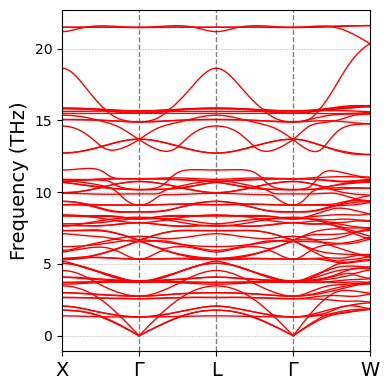

In [32]:
band_dict   = phonon.get_band_structure_dict()
frequencies = band_dict["frequencies"]   # 每一段的频率：list of (n_q, n_band)
distances = band_dict["frequencies"]

fig, ax = plt.subplots(figsize=(4, 4))

n_path  = len(frequencies)
x_ticks = []
x_labels = []
x_pos   = 0.0   # 当前段起点的 x

for i, f_seg in enumerate(frequencies):
    f_seg = np.array(f_seg)        # shape: (n_q, n_band)
    n_q   = f_seg.shape[0]

    # 把这一段在 x 方向放到 [x_pos, x_pos+1]
    x_seg = np.linspace(x_pos, x_pos + 1.0, n_q)

    # 画这一段的所有声子支（统一用红色）
    for band in f_seg.T:
        ax.plot(x_seg, band, color="red", linewidth=1.0)

    # x 轴刻度：第一段加起点，以后每段加终点
    if i == 0:
        x_ticks.append(x_seg[0])
        x_labels.append(labels[0])      # 第一个高对称点 X

    x_ticks.append(x_seg[-1])
    x_labels.append(labels[i + 1])      # 终点高对称点 Γ、L、Γ、W

    # 在段与段之间画粗一点的竖线（类似 grid 分隔）
    if i < n_path - 1:
        ax.axvline(x_seg[-1], color="grey",linestyle="--", linewidth=1.0)

    x_pos += 1.0    # 下一段往右平移 1 个单位

# 设置坐标轴
ax.set_xticks(x_ticks)
ax.set_xticklabels(x_labels, fontsize=14)
ax.set_xlim(x_ticks[0], x_ticks[-1])

ax.set_ylabel("Frequency (THz)", fontsize=14)
# 只开 y 方向的虚线网格
ax.grid(True, axis="y", linestyle="--", linewidth=0.4)

fig.tight_layout()
fig.savefig("phonon_band_merged.png", dpi=300)
plt.show()

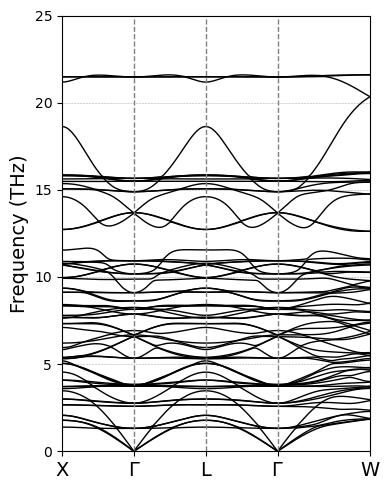

In [44]:
band_dict   = phonon.get_band_structure_dict()
dist_list   = band_dict["distances"]      # list of 1D arrays（已经是全局 distance）
freq_list   = band_dict["frequencies"]    # list of (n_q_seg, n_band)

# 把所有段拼到一根轴上
x_all   = np.hstack(dist_list)           # shape: (n_q_total,)
freq_all = np.vstack(freq_list)          # shape: (n_q_total, n_band)

# 每一段的 q 点数目，用来找分界位置
n_q_per_path   = [len(d) for d in dist_list]
bound_indices  = np.cumsum(n_q_per_path)   # 每一段结束的 index（1-based 结束）

fig, ax = plt.subplots(figsize=(4, 5))

# 画所有声子支
for band in freq_all.T:
    ax.plot(x_all, band, color="black", linewidth=1.0)

# ---- 画 x 轴刻度 & 竖向虚线分隔 ----
# 高对称点的位置：起点 + 每一段的终点
x_ticks  = [x_all[0]] + [x_all[i - 1] for i in bound_indices]
x_labels = labels  # 例如 ["X", "$\\Gamma$", "L", "$\\Gamma$", "W"]

ax.set_xticks(x_ticks)
ax.set_xticklabels(x_labels, fontsize=14)

# 段与段之间的虚线（最后一个不画）
for i in bound_indices[:-1]:
    ax.axvline(x_all[i - 1], color="grey", linestyle="--", linewidth=1.0)

ax.set_xlim(x_all[0], x_all[-1])
ax.set_ylim(0, 25)
ax.set_ylabel("Frequency (THz)", fontsize=14)
# 只开 y 方向虚线网格
ax.grid(True, axis="y", linestyle="--", linewidth=0.4)

fig.tight_layout()
fig.savefig("phonon_band_merged.png", dpi=300)
plt.show()